# Exploratory Data Analysis (EDA)

This section explores the merged dataset containing job postings and macro-level vacancy statistics from the Swiss Federal Statistical Office (BFS). The goal is to understand the structure of the dataset, identify potential data quality issues, and examine key variables before addressing the research questions.

## Import Libraries

In this step, the necessary Python libraries for data analysis and visualization are imported. Pandas is used for data manipulation, NumPy for numerical operations, and Matplotlib and Seaborn for visualizations.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Dataset

The dataset used in this analysis contains the merged job postings data (micro-level data) and macro labor market statistics obtained from BFS (macro-level data). The dataset is loaded from the processed data folder of the project repository.

In [17]:
df = pd.read_csv("../data/processed/jobs_micro_macro_merged_final.csv")

df.head()

,job_id,role,title,company,city,canton,region,quarter,macro_quarter,skills,skill_count,salary_available,industry,regional_vacancies,industry_vacancies,source,url,description
0,43725c60f2a0e7a20223831427ec1c5733c8e34c,data scientist,Mission étudiante 40% : Data Analyst,Academic Work Switzerland,Montreux,VD,Lake Geneva Region,2026Q1,2025Q4,['power bi'],1,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/a5de724a-4...,about the job tu es actuellement étudiant.e ? ...
1,929b4733c6e1c66d045413a3373023e435e25a0c,data scientist,Junior Survey Data Analyst 20%,Academic Work Switzerland,Lausanne,VD,Lake Geneva Region,2026Q1,2025Q4,[],0,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/366613c5-e...,about the job tu es étudiant.e et recherches u...
2,da46ba822882645bc160031dd473b01555e8e9c8,data scientist,Merchandising & Data Analyst (H/F),Vilebrequin,Plan-les-Ouates,GE,Lake Geneva Region,2026Q1,2025Q4,[],0,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/99ded019-3...,"about the job née en 1971 à st-tropez, la mais..."
3,face52ba0e66311274a47f6df9fbf699abc6bc3d,data scientist,Spécialiste informatique - Interfaces et donné...,Transports publics fribourgeois (TPF) SA,NaN,Unknown,NaN,2026Q1,2025Q4,"['python', 'sql', 'pandas']",3,0,58-63 ICT,NaN,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/6f302ed9-c...,about the job la mobilité est la raison d'être...
4,0e5906d2b6906c6f4eac077cdb6cda27d9955253,data scientist,Data Scientist - Innovation Collaborations,EPFL,Lausanne,VD,Lake Geneva Region,2026Q1,2025Q4,['machine learning'],1,0,58-63 ICT,13400.0,4362.0,jobup,https://www.jobup.ch/en/jobs/detail/fb39e340-5...,"about the job epfl, the swiss federal institut..."


## Dataset Overview

This section provides a general overview of the dataset. It includes information about the number of observations, the number of variables, and the data types of each column. Understanding the structure of the dataset is an important first step before performing further analysis.

In [18]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (743, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_id              743 non-null    object 
 1   role                743 non-null    object 
 2   title               743 non-null    object 
 3   company             743 non-null    object 
 4   city                247 non-null    object 
 5   canton              743 non-null    object 
 6   region              243 non-null    object 
 7   quarter             743 non-null    object 
 8   macro_quarter       743 non-null    object 
 9   skills              743 non-null    object 
 10  skill_count         743 non-null    int64  
 11  salary_available    743 non-null    int64  
 12  industry            743 non-null    object 
 13  regional_vacancies  243 non-null    float64
 14  industry_vacancies  743 non-null    float64
 15  source              743 non-null

## Missing Values

In this step, missing values are examined across all variables. Identifying missing data is important to understand potential limitations of the dataset and determine whether additional cleaning or adjustments may be required during analysis.

In [19]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

region                500
regional_vacancies    500
city                  496
job_id                  0
skill_count             0
url                     0
source                  0
industry_vacancies      0
industry                0
salary_available        0
skills                  0
role                    0
macro_quarter           0
quarter                 0
canton                  0
company                 0
title                   0
description             0
dtype: int64

The missing-value analysis shows that `city`, `region`, and `regional_vacancies` contain the largest number of missing values. This indicates that geographic information is not fully available for all postings, which may limit some regional comparisons in later analyses.

## Job Role Distribution


In [21]:
role_counts = df["role"].value_counts()

role_counts

role
data engineer                448
data scientist               122
data analyst                  95
machine learning engineer     42
ai engineer                   36
Name: count, dtype: int64

The distribution of roles shows that Data Analyst and Data Scientist positions appear most frequently in the dataset. This indicates a strong demand for analytical roles within the Swiss data job market. In contrast, more specialized roles such as AI Engineer and Machine Learning Engineer occur less often, suggesting that these positions are more niche and less widely advertised.

## Job Locations


In [23]:
canton_counts = df["canton"].value_counts()

canton_counts.head(10)

canton
Unknown    500
ZH          62
VD          43
BE          37
GE          20
VS          17
SG          17
AG          16
BS          13
LU          10
Name: count, dtype: int64

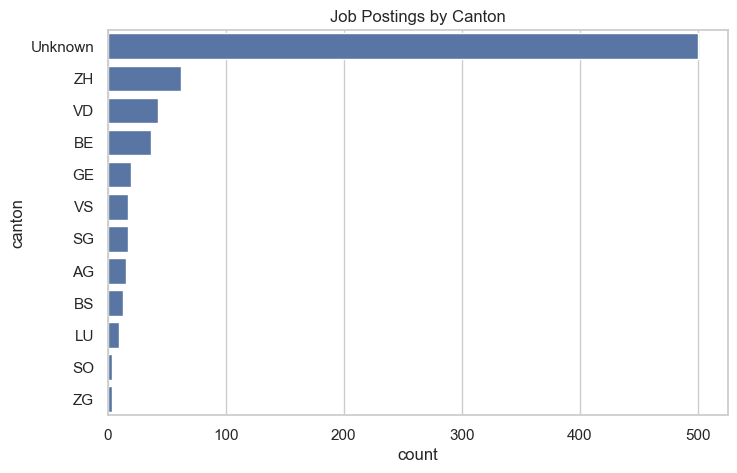

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="canton",
    data=df,
    order=df["canton"].value_counts().index
)

plt.title("Job Postings by Canton")

plt.show()

The geographic distribution shows that job postings are concentrated in a limited number of cantons. This suggests that data-related roles are more common in major economic and technology hubs in Switzerland, where demand for digital and analytical skills is likely to be highest.

## Salary Transparency

The results show that salary information is available only in a portion of job postings, indicating limited salary transparency in the Swiss job market. This supports the relevance of salary disclosure as a key analytical dimension in this project.

In [25]:
salary_rate = df["salary_available"].mean()

print("Salary transparency rate:", round(salary_rate*100,2), "%")

Salary transparency rate: 18.44 %


The observed salary transparency rate suggests that many employers do not include salary details directly in job advertisements. This may reflect common recruitment practices in which compensation information is disclosed only at later stages of the hiring process.

## Initial Observations

The exploratory analysis shows that the dataset contains 743 job postings related to data-oriented roles, including positions such as Data Analyst, Data Scientist, and Data Engineer.

The postings are concentrated in selected cantons and industries, reflecting the structure of the Swiss data job market. In addition, salary information is only available for a subset of advertisements, indicating limited salary transparency.

Overall, the EDA provides a solid foundation for the next stage of the project, where the research questions will be examined in more detail.